✓ Đã tải mBERT_freeze_full
✓ Đã tải mBERT_unfreeze
✓ Đã tải mBERT_freeze_embed
✓ Đã tải XLM_freeze_full
✓ Đã tải XLM_unfreeze
✓ Đã tải XLM_freeze_embed


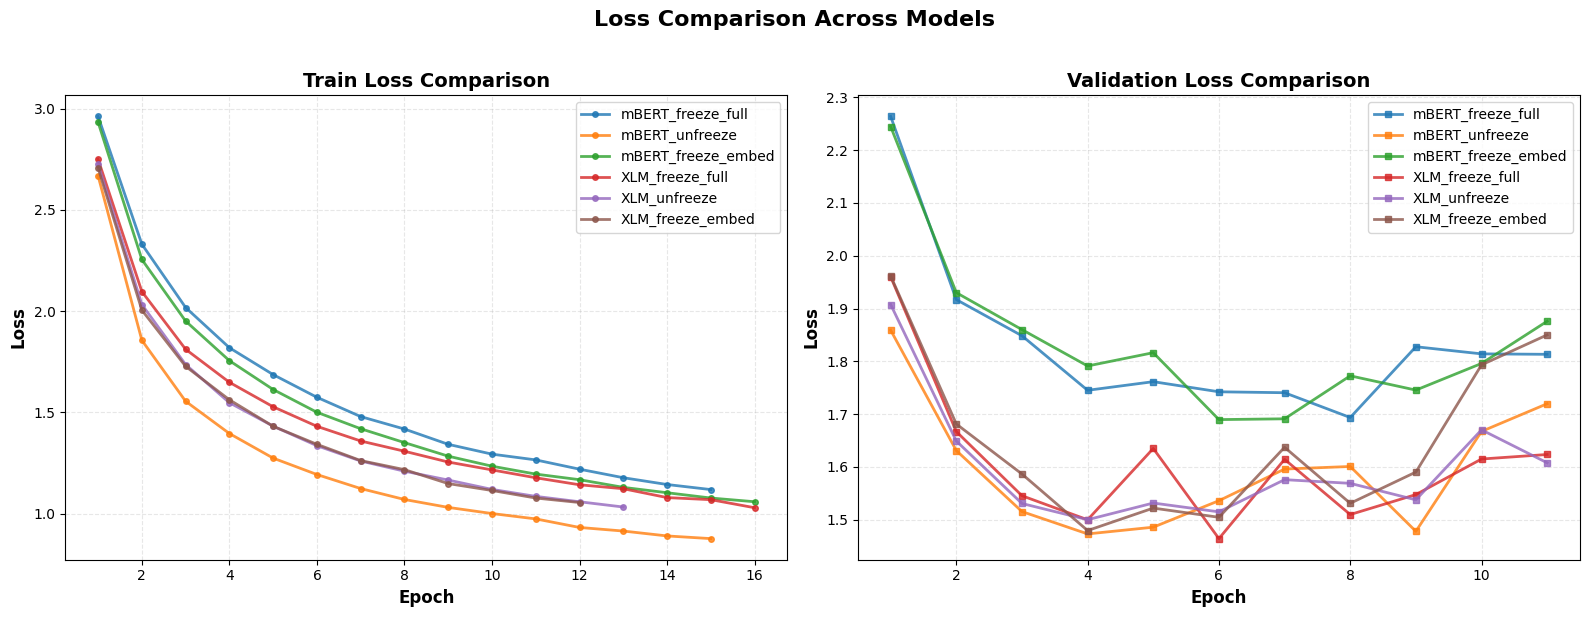

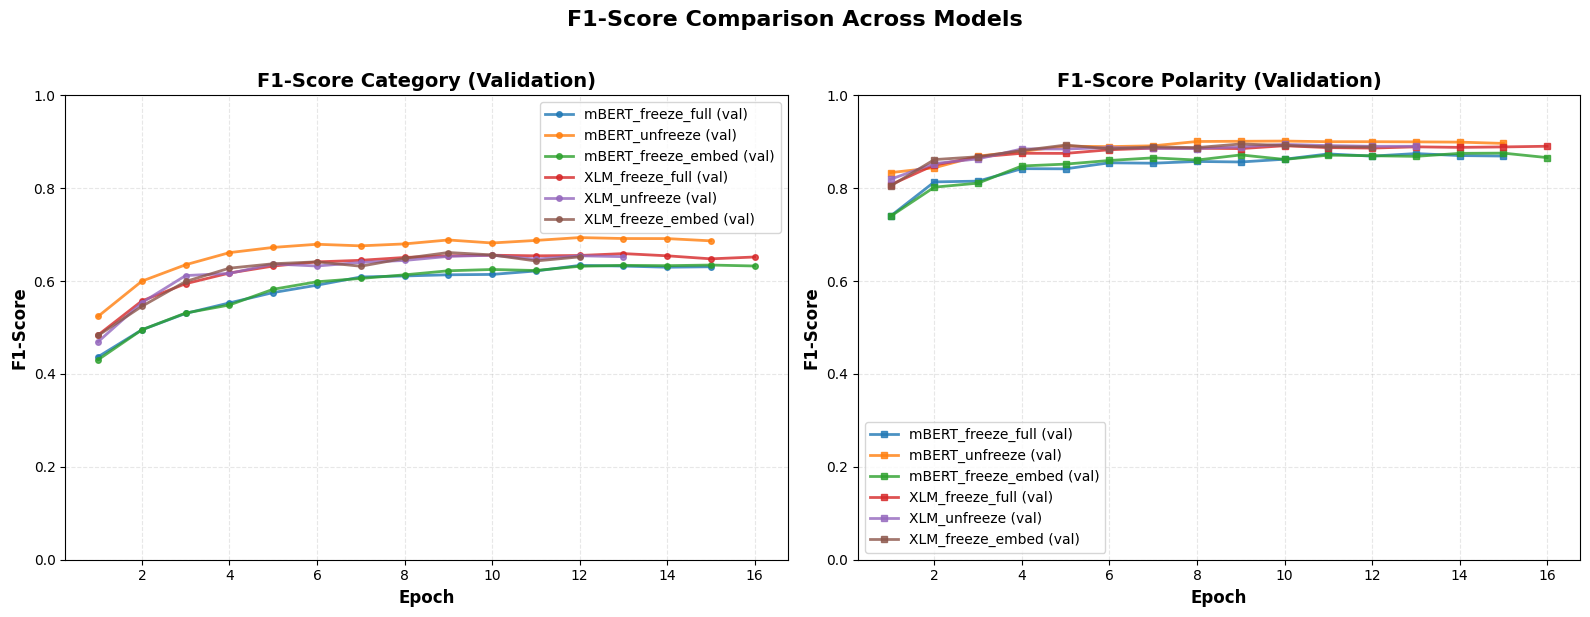

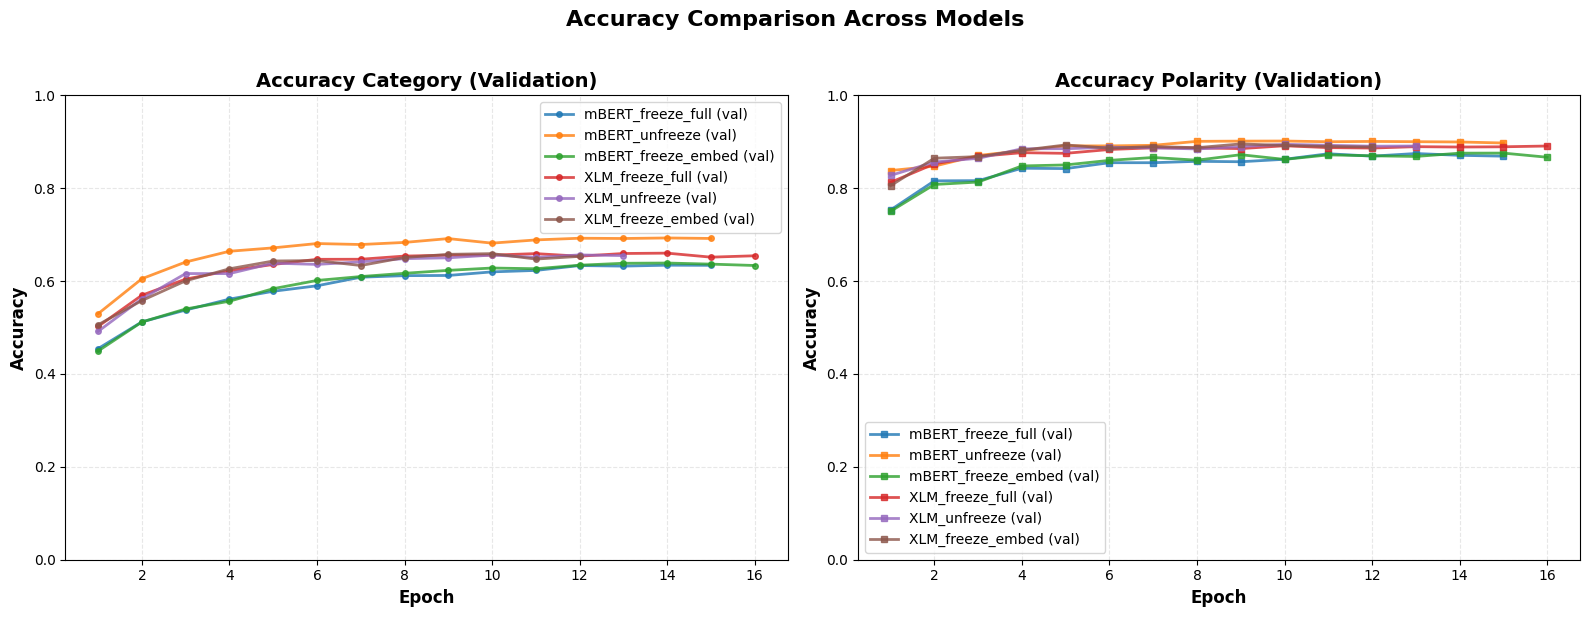

In [5]:
import pickle
import matplotlib.pyplot as plt
import numpy as np

# ===============================
# CẤU HÌNH - Tải metrics từ các file pkl
# ===============================
MODEL_METRICS = {}

# Đọc metrics từ các file đã lưu
MODEL_PATHS = {
    "mBERT_freeze_full": r"D:\2025-2026\ChuyenDe\pkl\mbert-full-freeze.pkl",
    "mBERT_unfreeze": r"D:\2025-2026\ChuyenDe\pkl\mbert-no-freeze.pkl",
    "mBERT_freeze_embed": r"D:\2025-2026\ChuyenDe\pkl\mbert-emb-freeze.pkl",
    "XLM_freeze_full": r"D:\2025-2026\ChuyenDe\pkl\xlm-full-freeze.pkl",
    "XLM_unfreeze": r"D:\2025-2026\ChuyenDe\pkl\xlm-no-freeze.pkl",
    "XLM_freeze_embed": r"D:\2025-2026\ChuyenDe\pkl\xlm-emb-freeze.pkl"
}

# Tải dữ liệu từng model
for model_name, path in MODEL_PATHS.items():
    try:
        with open(path, "rb") as f:
            MODEL_METRICS[model_name] = pickle.load(f)
        print(f"✓ Đã tải {model_name}")
    except FileNotFoundError:
        print(f"✗ Không tìm thấy {path}")

# ===============================
# MÀU SẮC VÀ STYLE
# ===============================
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
linestyles = ['-', '--', '-.', ':']

# ===============================
# FIGURE 1: TRAIN & VALIDATION LOSS
# ===============================
fig1, axes1 = plt.subplots(1, 2, figsize=(16, 6))

for idx, (model_name, metrics) in enumerate(MODEL_METRICS.items()):
    color = colors[idx % len(colors)]
    linestyle = linestyles[idx // len(colors)]
    
    # Train Loss
    epochs = range(1, len(metrics['train_losses']) + 1)
    axes1[0].plot(epochs, metrics['train_losses'], 
                  color=color, linestyle=linestyle, linewidth=2,
                  label=model_name, marker='o', markersize=4, alpha=0.8)
    
    # Validation Loss
    axes1[1].plot(epochs[:11], metrics['val_losses'][:11],
                   color=color, linestyle=linestyle, linewidth=2,
                   label=model_name, marker='s', markersize=4, alpha=0.8)

# Trang trí subplot Train Loss
axes1[0].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes1[0].set_ylabel('Loss', fontsize=12, fontweight='bold')
axes1[0].set_title('Train Loss Comparison', fontsize=14, fontweight='bold')
axes1[0].legend(loc='best', fontsize=10)
axes1[0].grid(True, alpha=0.3, linestyle='--')

# Trang trí subplot Validation Loss
axes1[1].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes1[1].set_ylabel('Loss', fontsize=12, fontweight='bold')
axes1[1].set_title('Validation Loss Comparison', fontsize=14, fontweight='bold')
axes1[1].legend(loc='best', fontsize=10)
axes1[1].grid(True, alpha=0.3, linestyle='--')

plt.suptitle('Loss Comparison Across Models', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ===============================
# FIGURE 2: F1-SCORE (CATEGORY & POLARITY)
# ===============================
fig2, axes2 = plt.subplots(1, 2, figsize=(16, 6))

for idx, (model_name, metrics) in enumerate(MODEL_METRICS.items()):
    color = colors[idx % len(colors)]
    linestyle = linestyles[idx // len(colors)]
    epochs = range(1, len(metrics['val_f1_category']) + 1)
    
    # F1 Category (Validation)
    axes2[0].plot(epochs, metrics['val_f1_category'], 
                  color=color, linestyle=linestyle, linewidth=2,
                  label=f'{model_name} (val)', marker='o', markersize=4, alpha=0.8)
    
    # F1 Polarity (Validation)
    axes2[1].plot(epochs, metrics['val_f1_polarity'], 
                  color=color, linestyle=linestyle, linewidth=2,
                  label=f'{model_name} (val)', marker='s', markersize=4, alpha=0.8)

# Trang trí subplot F1 Category
axes2[0].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes2[0].set_ylabel('F1-Score', fontsize=12, fontweight='bold')
axes2[0].set_title('F1-Score Category (Validation)', fontsize=14, fontweight='bold')
axes2[0].legend(loc='best', fontsize=10)
axes2[0].grid(True, alpha=0.3, linestyle='--')
axes2[0].set_ylim([0, 1])

# Trang trí subplot F1 Polarity
axes2[1].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes2[1].set_ylabel('F1-Score', fontsize=12, fontweight='bold')
axes2[1].set_title('F1-Score Polarity (Validation)', fontsize=14, fontweight='bold')
axes2[1].legend(loc='best', fontsize=10)
axes2[1].grid(True, alpha=0.3, linestyle='--')
axes2[1].set_ylim([0, 1])

plt.suptitle('F1-Score Comparison Across Models', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ===============================
# FIGURE 3: ACCURACY (CATEGORY & POLARITY)
# ===============================
fig3, axes3 = plt.subplots(1, 2, figsize=(16, 6))

for idx, (model_name, metrics) in enumerate(MODEL_METRICS.items()):
    color = colors[idx % len(colors)]
    linestyle = linestyles[idx // len(colors)]
    epochs = range(1, len(metrics['val_acc_category']) + 1)
    
    # Accuracy Category (Validation)
    axes3[0].plot(epochs, metrics['val_acc_category'], 
                  color=color, linestyle=linestyle, linewidth=2,
                  label=f'{model_name} (val)', marker='o', markersize=4, alpha=0.8)
    
    # Accuracy Polarity (Validation)
    axes3[1].plot(epochs, metrics['val_acc_polarity'], 
                  color=color, linestyle=linestyle, linewidth=2,
                  label=f'{model_name} (val)', marker='s', markersize=4, alpha=0.8)

# Trang trí subplot Accuracy Category
axes3[0].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes3[0].set_ylabel('Accuracy', fontsize=12, fontweight='bold')
axes3[0].set_title('Accuracy Category (Validation)', fontsize=14, fontweight='bold')
axes3[0].legend(loc='best', fontsize=10)
axes3[0].grid(True, alpha=0.3, linestyle='--')
axes3[0].set_ylim([0, 1])

# Trang trí subplot Accuracy Polarity
axes3[1].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes3[1].set_ylabel('Accuracy', fontsize=12, fontweight='bold')
axes3[1].set_title('Accuracy Polarity (Validation)', fontsize=14, fontweight='bold')
axes3[1].legend(loc='best', fontsize=10)
axes3[1].grid(True, alpha=0.3, linestyle='--')
axes3[1].set_ylim([0, 1])

plt.suptitle('Accuracy Comparison Across Models', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()



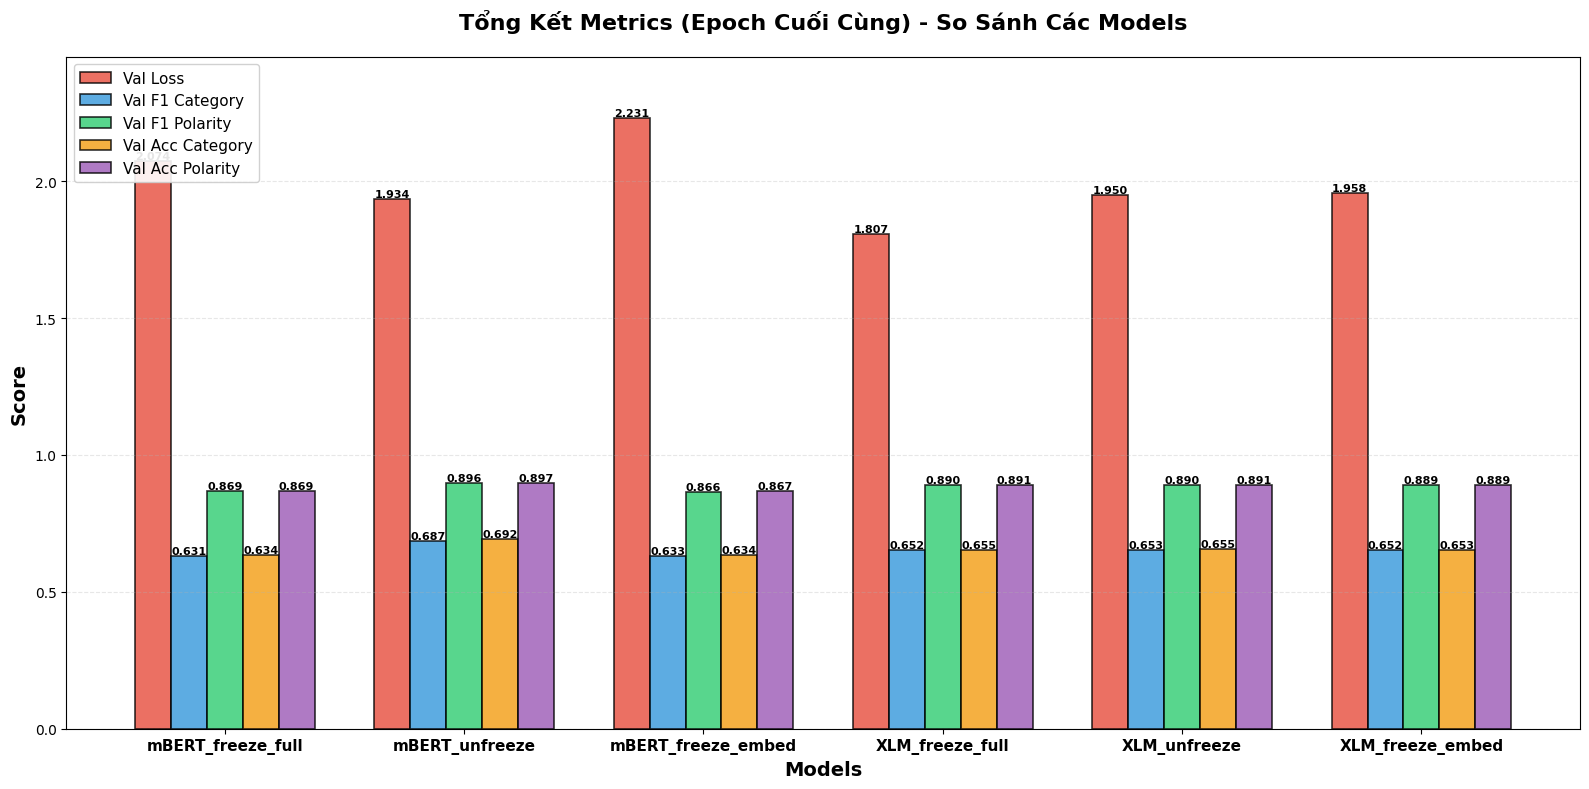

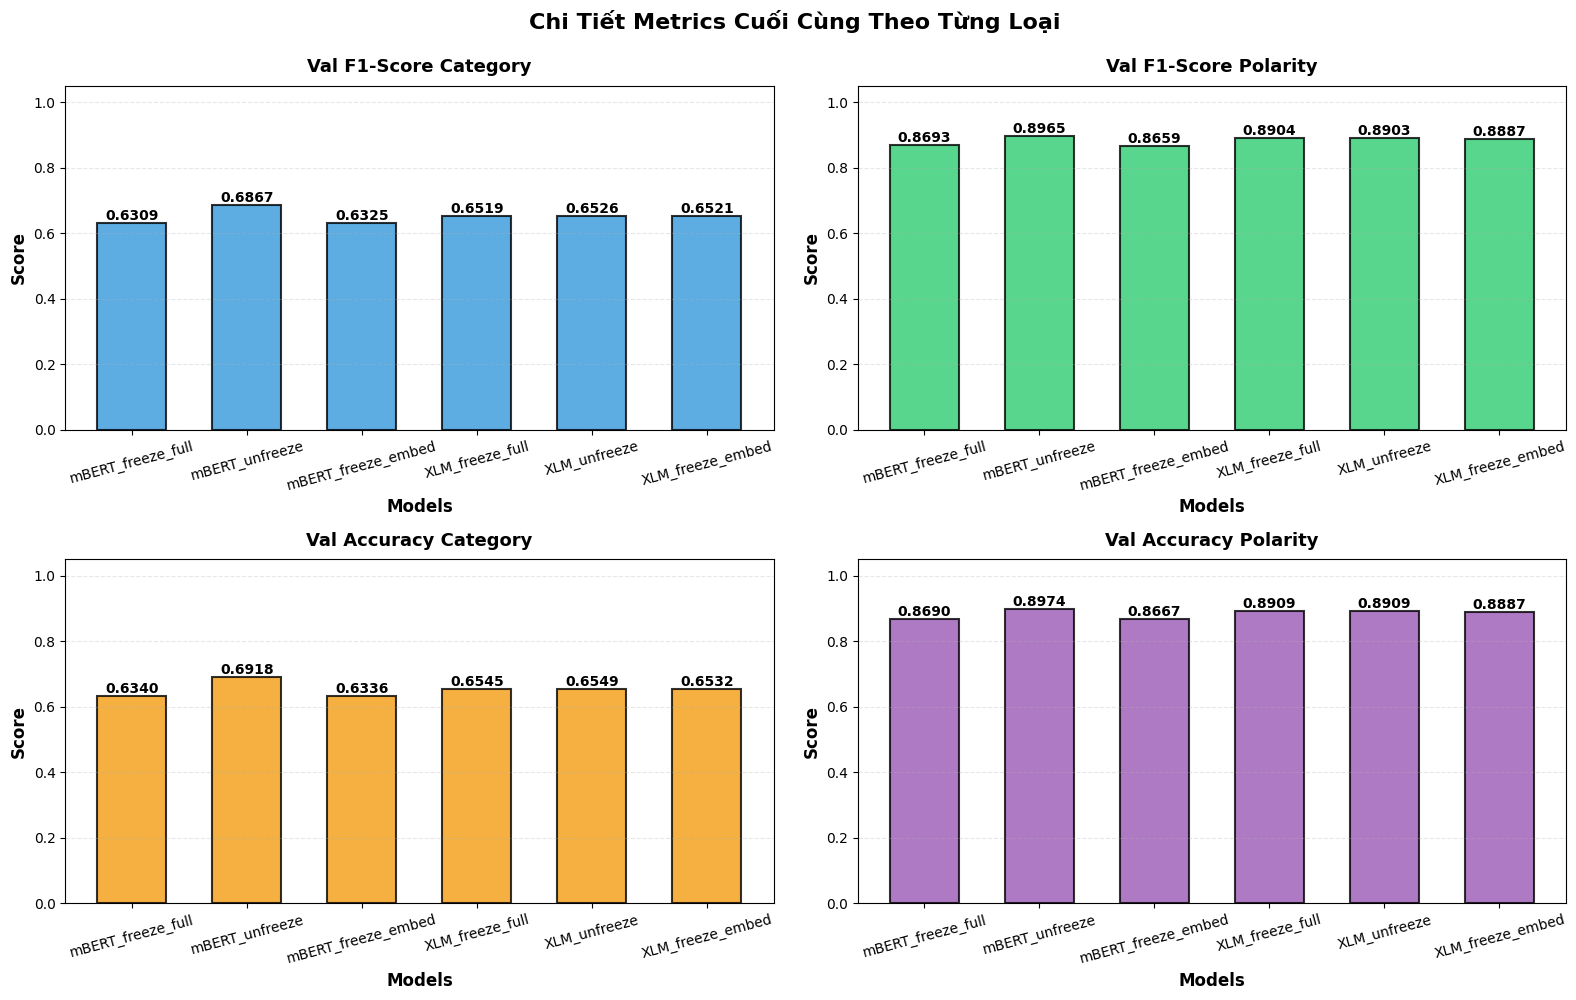


                                   BẢNG SO SÁNH METRICS CUỐI CÙNG
Model                         Val Loss     F1 Cat     F1 Pol    Acc Cat    Acc Pol
----------------------------------------------------------------------------------------------------
mBERT_freeze_full               2.0737     0.6309     0.8693     0.6340     0.8690
mBERT_unfreeze                  1.9341     0.6867     0.8965     0.6918     0.8974
mBERT_freeze_embed              2.2311     0.6325     0.8659     0.6336     0.8667
XLM_freeze_full                 1.8073     0.6519     0.8904     0.6545     0.8909
XLM_unfreeze                    1.9500     0.6526     0.8903     0.6549     0.8909
XLM_freeze_embed                1.9582     0.6521     0.8887     0.6532     0.8887

Best F1 Category:  mBERT_unfreeze (0.6867)
Best F1 Polarity:  mBERT_unfreeze (0.8965)
Lowest Val Loss:   XLM_freeze_full (1.8073)



In [6]:
# ===============================
# BIỂU ĐỒ CỘT: TỔNG KẾT METRICS EPOCH CUỐI CÙNG
# ===============================
import numpy as np

# Chuẩn bị dữ liệu
model_names = list(MODEL_METRICS.keys())
metrics_names = ['Val Loss', 'Val F1\nCategory', 'Val F1\nPolarity', 
                 'Val Acc\nCategory', 'Val Acc\nPolarity']

# Thu thập dữ liệu từ epoch cuối cùng
val_losses = [MODEL_METRICS[m]['val_losses'][-1] for m in model_names]
val_f1_cat = [MODEL_METRICS[m]['val_f1_category'][-1] for m in model_names]
val_f1_pol = [MODEL_METRICS[m]['val_f1_polarity'][-1] for m in model_names]
val_acc_cat = [MODEL_METRICS[m]['val_acc_category'][-1] for m in model_names]
val_acc_pol = [MODEL_METRICS[m]['val_acc_polarity'][-1] for m in model_names]

# ===============================
# FIGURE: BIỂU ĐỒ CỘT NHÓM
# ===============================
fig, ax = plt.subplots(figsize=(16, 8))

x = np.arange(len(model_names))
width = 0.15  # Độ rộng mỗi cột

# Vẽ các cột
bars1 = ax.bar(x - 2*width, val_losses, width, label='Val Loss', 
               color='#e74c3c', alpha=0.8, edgecolor='black', linewidth=1.2)
bars2 = ax.bar(x - width, val_f1_cat, width, label='Val F1 Category', 
               color='#3498db', alpha=0.8, edgecolor='black', linewidth=1.2)
bars3 = ax.bar(x, val_f1_pol, width, label='Val F1 Polarity', 
               color='#2ecc71', alpha=0.8, edgecolor='black', linewidth=1.2)
bars4 = ax.bar(x + width, val_acc_cat, width, label='Val Acc Category', 
               color='#f39c12', alpha=0.8, edgecolor='black', linewidth=1.2)
bars5 = ax.bar(x + 2*width, val_acc_pol, width, label='Val Acc Polarity', 
               color='#9b59b6', alpha=0.8, edgecolor='black', linewidth=1.2)

# Thêm giá trị trên mỗi cột
def add_value_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=8, fontweight='bold')

add_value_labels(bars1)
add_value_labels(bars2)
add_value_labels(bars3)
add_value_labels(bars4)
add_value_labels(bars5)

# Trang trí biểu đồ
ax.set_xlabel('Models', fontsize=14, fontweight='bold')
ax.set_ylabel('Score', fontsize=14, fontweight='bold')
ax.set_title('Tổng Kết Metrics (Epoch Cuối Cùng) - So Sánh Các Models', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=11, fontweight='bold')
ax.legend(loc='upper left', fontsize=11, framealpha=0.9)
ax.grid(True, axis='y', alpha=0.3, linestyle='--')
ax.set_ylim([0, max(max(val_losses), 1) * 1.1])  # Điều chỉnh theo loss

plt.tight_layout()
plt.show()

# ===============================
# FIGURE: BIỂU ĐỒ CỘT RIÊNG BIỆT (CHỈ F1 & ACCURACY)
# ===============================
fig2, axes = plt.subplots(2, 2, figsize=(16, 10))

metrics_data = [
    (val_f1_cat, 'Val F1-Score Category', '#3498db'),
    (val_f1_pol, 'Val F1-Score Polarity', '#2ecc71'),
    (val_acc_cat, 'Val Accuracy Category', '#f39c12'),
    (val_acc_pol, 'Val Accuracy Polarity', '#9b59b6')
]

for idx, (data, title, color) in enumerate(metrics_data):
    row = idx // 2
    col = idx % 2
    
    bars = axes[row, col].bar(model_names, data, color=color, alpha=0.8, 
                               edgecolor='black', linewidth=1.5, width=0.6)
    
    # Thêm giá trị trên mỗi cột
    for bar in bars:
        height = bar.get_height()
        axes[row, col].text(bar.get_x() + bar.get_width()/2., height,
                            f'{height:.4f}',
                            ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    # Trang trí
    axes[row, col].set_xlabel('Models', fontsize=12, fontweight='bold')
    axes[row, col].set_ylabel('Score', fontsize=12, fontweight='bold')
    axes[row, col].set_title(title, fontsize=13, fontweight='bold', pad=10)
    axes[row, col].set_ylim([0, 1.05])
    axes[row, col].grid(True, axis='y', alpha=0.3, linestyle='--')
    axes[row, col].tick_params(axis='x', rotation=15)

plt.suptitle('Chi Tiết Metrics Cuối Cùng Theo Từng Loại', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# ===============================
# BẢNG SO SÁNH (TEXT)
# ===============================
print("\n" + "="*100)
print(" "*35 + "BẢNG SO SÁNH METRICS CUỐI CÙNG")
print("="*100)
print(f"{'Model':<25} {'Val Loss':>12} {'F1 Cat':>10} {'F1 Pol':>10} {'Acc Cat':>10} {'Acc Pol':>10}")
print("-"*100)

for i, model_name in enumerate(model_names):
    print(f"{model_name:<25} {val_losses[i]:>12.4f} {val_f1_cat[i]:>10.4f} "
          f"{val_f1_pol[i]:>10.4f} {val_acc_cat[i]:>10.4f} {val_acc_pol[i]:>10.4f}")

print("="*100)

# Tìm model tốt nhất
best_f1_cat_idx = np.argmax(val_f1_cat)
best_f1_pol_idx = np.argmax(val_f1_pol)
best_loss_idx = np.argmin(val_losses)

print(f"\nBest F1 Category:  {model_names[best_f1_cat_idx]} ({val_f1_cat[best_f1_cat_idx]:.4f})")
print(f"Best F1 Polarity:  {model_names[best_f1_pol_idx]} ({val_f1_pol[best_f1_pol_idx]:.4f})")
print(f"Lowest Val Loss:   {model_names[best_loss_idx]} ({val_losses[best_loss_idx]:.4f})")
print("="*100 + "\n")